>>> [1/5] 正在生成场景并执行 GNN 训练 (seed=4, lambda=0.1)...
>>> [1/3] 初始化协同定位物理场景...
>>> [2/3] 计算稠密全图基准 CRLB...
    原始稠密图边数: 90
    原始稠密图 CRLB: 10055.1953

>>> [3/3] 开始 GNN 剪枝训练...
Epoch 000 | Total Loss: 4.1909 | CRLB: 329961.5312 (是基准的 32.82 倍) | 保留边数: 7/90 | Tau: 0.997
Epoch 020 | Total Loss: 5.2082 | CRLB: 50213.2695 (是基准的 4.99 倍) | 保留边数: 36/90 | Tau: 0.941
Epoch 040 | Total Loss: 4.5036 | CRLB: 20322.6230 (是基准的 2.02 倍) | 保留边数: 38/90 | Tau: 0.889
Epoch 060 | Total Loss: 4.6036 | CRLB: 20321.8516 (是基准的 2.02 倍) | 保留边数: 39/90 | Tau: 0.839
Epoch 080 | Total Loss: 4.8037 | CRLB: 30319.1523 (是基准的 3.02 倍) | 保留边数: 37/90 | Tau: 0.792
Epoch 100 | Total Loss: 5.0874 | CRLB: 40266.4258 (是基准的 4.00 倍) | 保留边数: 37/90 | Tau: 0.748
Epoch 120 | Total Loss: 4.6036 | CRLB: 20321.8516 (是基准的 2.02 倍) | 保留边数: 39/90 | Tau: 0.706
Epoch 140 | Total Loss: 4.6030 | CRLB: 20309.7246 (是基准的 2.02 倍) | 保留边数: 39/90 | Tau: 0.666
Epoch 160 | Total Loss: 4.7005 | CRLB: 20258.5996 (是基准的 2.01 倍) | 保留边数: 40/90 | Tau: 0.629
Epoch 18

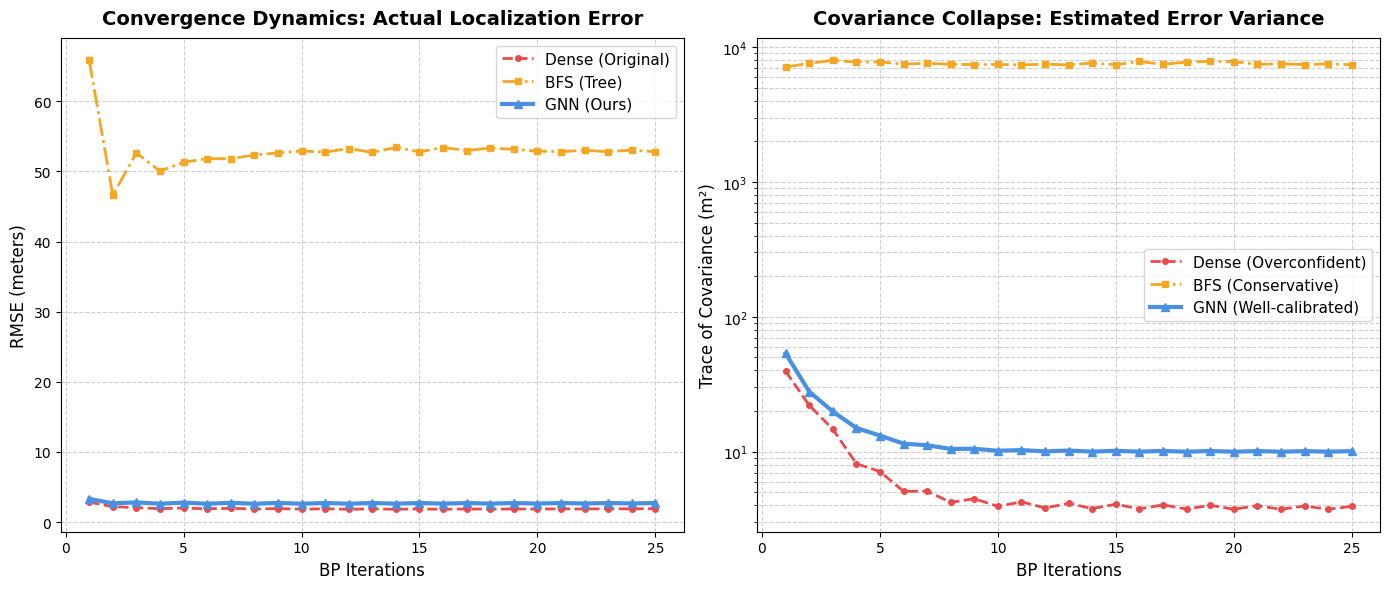

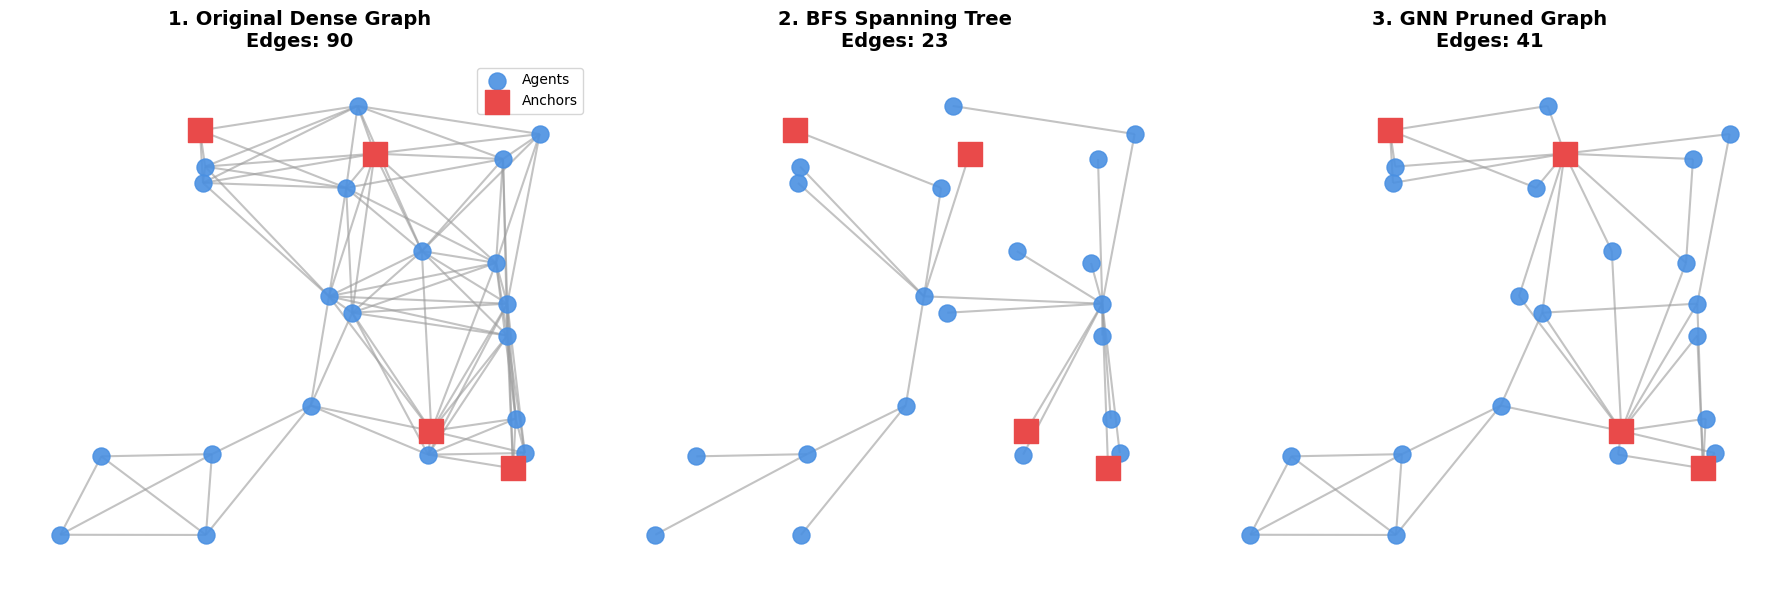

In [ ]:
import torch
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 导入各个模块
from GNN_learning.train import train_gnn_sparsifier
from NBP_ST.BFS_tree import extract_bfs_tree_edges
from GNN_learning.visualize_topology import plot_topology_comparison

TORCH_SEED = 4          # 随机种子
LAMBDA_REG = 0.1       # 超参数 lambda
EPOCHS = 1000
NUM_ITERS = 25          # BP 迭代次数
TOLERANCE = 1e-1        # 判断 BP 收敛的阈值

def calculate_metrics(estimated_pos, true_pos, estimated_sigma, e_th=3.0, alpha=0.05):
    """
    计算包含 NEES 和 Outage Probability 在内的评价指标
    :param e_th: 中断概率的误差容忍阈值 (例如 3.0 米)
    :param alpha: 卡方检验的显著性水平 (0.05 对应 95% 置信度)
    """
    
    N = estimated_pos.shape[0]
    errors = estimated_pos - true_pos

    # ==========================================
    # 1. 基础物理指标 (RMSE)
    # ==========================================
    distances = torch.norm(errors, dim=1)
    rmse = torch.sqrt(torch.mean(distances**2)).item()

    # ==========================================
    # 2. 中断概率 (Outage Probability)
    # ==========================================
    # 统计距离超过阈值 e_th 的节点比例
    outage_prob = (distances > e_th).float().mean().item()
    
    # ==========================================
    # 3. 一致性分析 (NEES & 卡方检验)
    # ==========================================
    nees_list = []
    for i in range(N):
        # 提取单个节点的误差向量 (2x1) 和协方差矩阵 (2x2)
        e_i = errors[i].unsqueeze(1) 
        sigma_i = estimated_sigma[i]
        
        try:
            # 计算马氏距离的平方 (NEES)
            sigma_inv = torch.linalg.inv(sigma_i)
            nees = torch.mm(torch.mm(e_i.T, sigma_inv), e_i).item()
        except RuntimeError:
            # 防止极个别孤立节点奇异矩阵报错
            nees = float('inf') 
            
        nees_list.append(nees)
        
    nees_array = np.array(nees_list)
    
    # 根据 2 自由度卡方分布，计算接受假设 H0 的上下界
    # 理想情况下，95% 的节点其 NEES 应该落在这个区间内
    r1 = stats.chi2.ppf(alpha / 2, df=2)       # 下界 (约 0.051)
    r2 = stats.chi2.ppf(1 - alpha / 2, df=2)   # 上界 (约 7.378)
    
    # 统计有多少比例的节点落在了置信区间内 (Consistency Rate)
    consistent_nodes = ((nees_array >= r1) & (nees_array <= r2)).sum()
    consistency_rate = consistent_nodes / N
    
    # 顺便计算一下平均 NEES (理想值应该趋近于自由度 2.0)
    mean_nees = np.mean(nees_array[nees_array != float('inf')])
    
    return rmse, outage_prob, consistency_rate, mean_nees

def gaussian_bp_evaluator(agents_pos_init, agents_pos_true, anchors_pos, edge_index, measurements, edge_variances, is_anchor_edge, edge_weights=None, num_iters=25, tol=1e-3):
    """
    [终极融合版裁判员]：不仅计算最终收敛状态，还同步记录迭代过程的动态历史。
    返回: mu, Sigma, actual_iters, history_rmse, history_trace
    """
    N = agents_pos_init.shape[0]
    E = edge_index.shape[1]
    
    if edge_weights is None:
        edge_weights = torch.ones(E, device=agents_pos_init.device)
        
    mu = agents_pos_init.clone()
    Sigma = torch.eye(2).unsqueeze(0).repeat(N, 1, 1) * 100.0 
    J_prior = torch.eye(2) * 1e-4
    h_prior = torch.zeros(2) 
    
    actual_iters = num_iters 
    history_rmse = []
    history_trace = []
    
    for it in range(num_iters):
        mu_old = mu.clone() 
        J_new = J_prior.unsqueeze(0).repeat(N, 1, 1)
        h_new = h_prior.unsqueeze(0).repeat(N, 1)
        
        # --- 消息传递 ---
        for e in range(E):
            w = edge_weights[e]
            if w < 1e-3: continue
                
            idx_u = edge_index[0, e] 
            idx_v = edge_index[1, e] 
            
            if is_anchor_edge[e]:
                pos_v = anchors_pos[idx_v]
                Sigma_v = torch.zeros(2, 2) 
            else:
                pos_v = mu[idx_v]
                Sigma_v = Sigma[idx_v]
                
            pos_u = mu[idx_u]

            # 前向
            diff = pos_u - pos_v
            dist = torch.norm(diff) + 1e-8
            u_vec = (diff / dist).view(2, 1) 
            proj_var_v = torch.mm(torch.mm(u_vec.T, Sigma_v), u_vec).squeeze()
            msg_var_vu = edge_variances[e] + proj_var_v
            z_pos_u = pos_v + measurements[e] * u_vec.squeeze()
            J_msg_vu = (w / msg_var_vu) * torch.mm(u_vec, u_vec.T)
            h_msg_vu = torch.mv(J_msg_vu, z_pos_u)
            J_new[idx_u] += J_msg_vu
            h_new[idx_u] += h_msg_vu

            # 反向
            if not is_anchor_edge[e]:
                u_vec_rev = -u_vec 
                Sigma_u = Sigma[idx_u]
                proj_var_u = torch.mm(torch.mm(u_vec_rev.T, Sigma_u), u_vec_rev).squeeze()
                msg_var_uv = edge_variances[e] + proj_var_u
                z_pos_v = pos_u + measurements[e] * u_vec_rev.squeeze()
                J_msg_uv = (w / msg_var_uv) * torch.mm(u_vec_rev, u_vec_rev.T)
                h_msg_uv = torch.mv(J_msg_uv, z_pos_v)
                J_new[idx_v] += J_msg_uv
                h_new[idx_v] += h_msg_uv
                
        # --- 信念更新 ---
        for i in range(N):
            try:
                Sigma[i] = torch.linalg.inv(J_new[i])
                mu[i] = torch.mv(Sigma[i], h_new[i])
            except RuntimeError:
                pass

        # --- 记录动态历史 ---
        errors = mu - agents_pos_true
        rmse = torch.sqrt(torch.mean(torch.sum(errors**2, dim=1))).item()
        trace = torch.mean(torch.diagonal(Sigma, dim1=-2, dim2=-1).sum(dim=-1)).item()
        history_rmse.append(rmse)
        history_trace.append(trace)

        # --- 收敛检查 (Early Stopping) ---
        max_pos_change = torch.max(torch.norm(mu - mu_old, dim=1))
        if max_pos_change < tol:
            actual_iters = it + 1 
            break 
            
    return mu, Sigma, actual_iters, history_rmse, history_trace

def plot_dynamics(hist_rmse_d, hist_trace_d, hist_rmse_b, hist_trace_b, hist_rmse_g, hist_trace_g):
    """绘制迭代过程的动态折线图，支持处理早停导致的不同长度数组"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 动态生成 X 轴 (因为不同方法可能在不同迭代次数触发了早停)
    iters_d = np.arange(1, len(hist_rmse_d) + 1)
    iters_b = np.arange(1, len(hist_rmse_b) + 1)
    iters_g = np.arange(1, len(hist_rmse_g) + 1)
    
    # --- 图 1：RMSE 真实误差收敛图 ---
    ax1.plot(iters_d, hist_rmse_d, label='Dense (Original)', color='#E94A4A', linestyle='--', linewidth=2, marker='o', markersize=4)
    ax1.plot(iters_b, hist_rmse_b, label='BFS (Tree)', color='#F5A623', linestyle='-.', linewidth=2, marker='s', markersize=4)
    ax1.plot(iters_g, hist_rmse_g, label='GNN (Ours)', color='#4A90E2', linestyle='-', linewidth=3, marker='^', markersize=6)
    
    ax1.set_title('Convergence Dynamics: Actual Localization Error', fontsize=14, fontweight='bold', pad=10)
    ax1.set_xlabel('BP Iterations', fontsize=12)
    ax1.set_ylabel('RMSE (meters)', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(fontsize=11)
    
    # --- 图 2：Trace 自信度坍塌图 ---
    ax2.plot(iters_d, hist_trace_d, label='Dense (Overconfident)', color='#E94A4A', linestyle='--', linewidth=2, marker='o', markersize=4)
    ax2.plot(iters_b, hist_trace_b, label='BFS (Conservative)', color='#F5A623', linestyle='-.', linewidth=2, marker='s', markersize=4)
    ax2.plot(iters_g, hist_trace_g, label='GNN (Well-calibrated)', color='#4A90E2', linestyle='-', linewidth=3, marker='^', markersize=6)
    
    ax2.set_yscale('log')
    ax2.set_title('Covariance Collapse: Estimated Error Variance', fontsize=14, fontweight='bold', pad=10)
    ax2.set_xlabel('BP Iterations', fontsize=12)
    ax2.set_ylabel('Trace of Covariance (m²)', fontsize=12)
    ax2.grid(True, which="both", linestyle='--', alpha=0.6)
    ax2.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    torch.manual_seed(TORCH_SEED)
    
    # ==========================================
    # 1. 数据准备与图拓扑生成
    # ==========================================
    print(f">>> [1/5] 正在生成场景并执行 GNN 训练 (seed={TORCH_SEED}, lambda={LAMBDA_REG})...")
    model, gnn_weights, data, final_edges, crlb_final, crlb_baseline = train_gnn_sparsifier(
        epochs=EPOCHS, lr=0.01, lambda_reg=LAMBDA_REG
    )
    
    agents_pos_true = data['true_agents_pos']
    agents_pos_init = data['init_agents_pos']
    anchors_pos = data['anchors_pos']
    edge_index = data['edge_index']
    measurements = data['measurements']
    edge_variances = data['edge_variances']
    is_anchor_edge = data['is_anchor_edge']
    E_total = edge_index.shape[1]
    
    print(f"\n>>> [2/4] 正在提取 BFS 树...")
    bfs_weights = extract_bfs_tree_edges(agents_pos_true.shape[0], anchors_pos.shape[0], edge_index, is_anchor_edge)
    
    dense_weights = torch.ones(E_total)
    
    # ==========================================
    # 2. 将三种拓扑输入高斯 BP 算法进行迭代
    # ==========================================
    print("\n>>> [3/5] 正在运行 Gaussian BP 定位...")
    
    # 测试 A：原图 (Dense)
    mu_dense, sigma_dense, iters_dense, hist_rmse_d, hist_trace_d = gaussian_bp_evaluator(
        agents_pos_init, agents_pos_true, anchors_pos, edge_index, measurements, edge_variances, 
        is_anchor_edge, edge_weights=dense_weights, num_iters=NUM_ITERS, tol=TOLERANCE
    )
    
    # 测试 B：BFS 树 (Tree)
    mu_bfs, sigma_bfs, iters_bfs, hist_rmse_b, hist_trace_b = gaussian_bp_evaluator(
        agents_pos_init, agents_pos_true, anchors_pos, edge_index, measurements, edge_variances, 
        is_anchor_edge, edge_weights=bfs_weights, num_iters=NUM_ITERS, tol=TOLERANCE
    )
    
    # 测试 C：GNN 稀疏图 (Sparse)
    mu_gnn, sigma_gnn, iters_gnn, hist_rmse_g, hist_trace_g = gaussian_bp_evaluator(
        agents_pos_init, agents_pos_true, anchors_pos, edge_index, measurements, edge_variances, 
        is_anchor_edge, edge_weights=gnn_weights, num_iters=NUM_ITERS, tol=TOLERANCE
    )
    
    # ==========================================
    # 3. 结果核算与打印
    # ==========================================
    print("\n>>> [4/4] 结果核算中...")
    print("=" * 115)
    print(f"{'拓扑模型':<10} | {'边数':<3} | {'迭代':<3} | {'RMSE (m)':<9} | {'中断概率 (3m)':<9} | {'平均 NEES':<9} | {'一致性达标率 (95% CI)':<20}")
    print("-" * 115)
    
    # Dense 统计
    rmse_dense, out_dense, cons_dense, nees_dense = calculate_metrics(mu_dense, agents_pos_true, sigma_dense, e_th=3.0)
    print(f"{'1. 原图':<12} | {E_total:<4} | {iters_dense:<4} | {rmse_dense:<10.4f} | {out_dense*100:<11.1f}% | {nees_dense:<10.1f} | {cons_dense*100:<5.1f}%")
    
    # BFS 统计
    rmse_bfs, out_bfs, cons_bfs, nees_bfs = calculate_metrics(mu_bfs, agents_pos_true, sigma_bfs, e_th=3.0)
    edges_bfs = int(torch.sum(bfs_weights).item())
    print(f"{'2. BFS 树':<13} | {edges_bfs:<4} | {iters_bfs:<4} | {rmse_bfs:<10.4f} | {out_bfs*100:<11.1f}% | {nees_bfs:<10.1f} | {cons_bfs*100:<5.1f}%")
    
    # GNN 统计
    rmse_gnn, out_gnn, cons_gnn, nees_gnn = calculate_metrics(mu_gnn, agents_pos_true, sigma_gnn, e_th=3.0)
    edges_gnn = int(torch.sum(gnn_weights).item())
    print(f"{'3. GNN 剪枝':<12} | {edges_gnn:<4} | {iters_gnn:<4} | {rmse_gnn:<10.4f} | {out_gnn*100:<11.1f}% | {nees_gnn:<10.1f} | {cons_gnn*100:<5.1f}%")
    print("=" * 115)

    # ==========================================
    # 4. 可视化图表
    # ==========================================
    print("\n>>> [5/5] 正在生成可视化图表...")
    
    # 图表 1: 迭代动态折线图
    plot_dynamics(hist_rmse_d, hist_trace_d, hist_rmse_b, hist_trace_b, hist_rmse_g, hist_trace_g)
    
    # 图表 2: 网络拓扑对比图
    plot_topology_comparison(data, gnn_weights, bfs_weights)